# GP on various (1D) functions 

In this notebook, the process of 1D function prediction followed in the [intro notebook](./notebook_test_GP.py) is applied to different types of functions. The code detailed from that notebook has been generalised to a `Surrogate` class in `exact_gp_model.py` that wraps the workflow from defining the test function to obtaining infered values. 

Specifically, the a class `Surrogate` model is defined that can be instanciated with: 
- a Callable `func` object that represents the function
- a tuple `bounds` that represent the bounds on which the function should be modeled
- a boolean `noise` that decides whether observation noise should be assumed on the data (internally, this sets the likelihood of the used GP model to either a fixed gaussian noise with tiny variance, or a learned noise)
- a training sample size `sample_size` that decides the number of randomly observed points to start with
- (optionally) an input sample `input_sample`: If given, this overrides the random training sample generation and `input_sample` is used instead. 

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np 
import torch 
from matplotlib import pyplot as plt 

In [2]:
## Runs the test 
## %run exact_gp_model.py

## Effect of input sampling strategies 

The input sampling strategy is roughly the method of choosing the training points in the input space. From a purely interpolation point of view, their distribution can affect the efficiency of the final reconstruction. As extreme examples, the following GP models of the same function illustrate why sampling matters. 

At a fixed training sample size $N=10$, three sampling methods are used: a (purely) random sample from an uniform distribution, an sample with 10 equally spaced points, a [pseudo-random sample](https://en.wikipedia.org/wiki/Latin_hypercube_sampling).

In [16]:
from exact_gp_model import Surrogate 
from scipy.stats import qmc 

def f(x):
    return torch.cos(torch.sin(x)) * torch.cos(x)

bounds = (-10, 10)
sample_size = 10

random_sample = torch.from_numpy(np.random.uniform(bounds[0], bounds[1], sample_size))
spaced_sample = torch.linspace(bounds[0], bounds[1], sample_size)

qmc_sample = qmc.LatinHypercube(d=1, scramble=True).random(sample_size)
qmc_sample = (1 - qmc_sample) * bounds[0] + qmc_sample * bounds[1] 
lhs_sample = torch.from_numpy(qmc_sample.reshape(sample_size,)) 

samples = {
    "Random": random_sample,
    "Equally spaced": spaced_sample,
    "LHS": lhs_sample
}

gps = {
    sample_name: Surrogate(
        func=f,
        bounds=bounds,
        noise=False,
        input_sample=sample
    )

    for sample_name, sample in samples.items()
}

train_results = {}

training_iters = 50 
for gp, model in gps.items():
    train_results[gp] = model.train(training_iters=50, details=True)

Text(0.5, 0.98, 'Different prediction means from different training sample strategies')

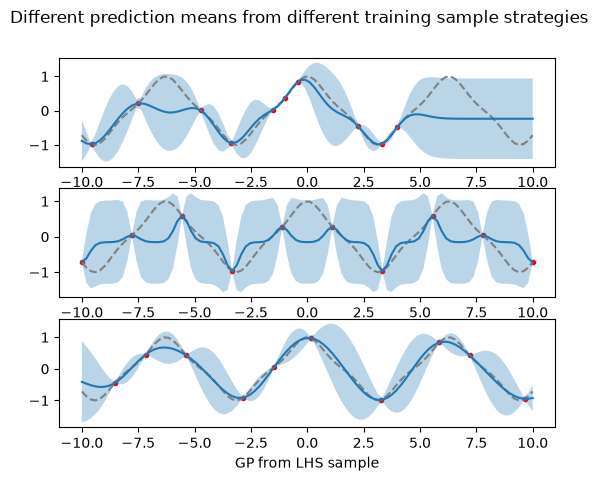

In [17]:
fig, axes = plt.subplots(3)
axes = axes.flatten() 

test_x = torch.linspace(*bounds, 100)


i=0
for name, model in gps.items(): 
    train_x, train_y = model.get_training_data() 
    ## true function 
    axes[i].plot(test_x, f(test_x), color='grey', linestyle='--', label='Initial function')

    ## training sample 
    axes[i].scatter(train_x, train_y, color='red', marker='.')
    
    model_y, lower_conf, upper_conf = model(test_x)
    axes[i].plot(test_x, model_y, linestyle='-')

    axes[i].fill_between(test_x, lower_conf, upper_conf, alpha=0.3)

    axes[i].set_xlabel(f"GP from {name} sample")
    i+= 1 

plt.suptitle("Different prediction means from different training sample strategies")
    

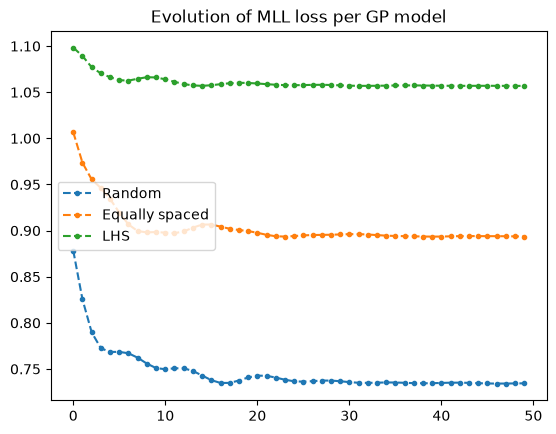

In [19]:
## Show training evolution 
plt.figure() 
for name, model in gps.items():
    plt.plot(range(training_iters), train_results[name]["loss"], label=name, marker='.', linestyle='--')

plt.title("Evolution of MLL loss per GP model")
plt.legend() 